# Exploratory Data Analysis 

## Librerias

In [57]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

## Carga de fichero csv

In [58]:
df_fichero = pd.read_csv(
    "../Data/Fuentes externas/ECF/BBDD/ecf_2021.csv",
    sep=";"
)

## 1. Exploratory Data Analysis (previo a Recodificación)

In [59]:
# Dimensiones del dataset
df_fichero.shape

(7764, 429)

In [60]:
# Listado de columnas/variables
print(df_fichero.columns.tolist())

['a01', 'a02', 'a0000', 'a0400', 'a04', 'a0800', 'a0100', 'a0320', 'a1030', 'a1040', 'a0910', 'a1100', 'a1200', 'a1300', 'a1400', 'a1410', 'a1420a', 'a1420b', 'a1420c', 'a1420d', 'a1420e', 'a1420f', 'a1420g', 'a1500', 'a1510', 'a1600', 'a1520', 'a1530', 'a2000', 'a1700', 'a1710', 'a1900', 'a2100', 'a2200', 'a2300', 'a2500', 'a2400', 'a2600', 'a2700', 'b0100', 'b0110a', 'b0110b', 'b0110c', 'b0110d', 'b0110e', 'b0110f', 'b0110g', 'b0120a', 'b0120b', 'b0120c', 'b0120d', 'b0120e', 'b0120f', 'b0130a', 'b0130b', 'b0130c', 'b0208', 'b0308', 'b0408', 'b0201', 'b0301', 'b0401', 'b0202', 'b0302', 'b0402', 'b0203', 'b0303', 'b0403', 'b0204', 'b0304', 'b0404', 'b0205', 'b0305', 'b0405', 'b0206', 'b0306', 'b0406', 'b0207', 'b0307', 'b0407', 'b0209', 'b0309', 'b0409', 'b0210', 'b0310', 'b0410', 'b0212', 'b0312', 'b0412', 'b1100a', 'b1100b', 'b1100c', 'b1100d', 'b1100e', 'b1100f', 'b1100g', 'b1100i', 'b1100h', 'b0502', 'b0503', 'b0600', 'b0720a', 'b0720b', 'b0720c', 'b0720d', 'b0720e', 'b0720f', 'b07

In [61]:
# Info general del dataset y tipos de datos
df_fichero.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7764 entries, 0 to 7763
Columns: 429 entries, a01 to ID
dtypes: float64(10), int64(419)
memory usage: 25.4 MB


In [62]:
# % de datos faltantes entre columnas
miss = (
    df_fichero.isna()
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
      .to_frame("missing_pct")
)
display(miss.head())

,missing_pct
a01,0.0
i0700,0.0
i0601,0.0
i0520g,0.0
i0520d,0.0


In [63]:
# Valores únicos por columna
nunique = df_fichero.nunique(dropna=True).sort_values()
display(nunique.head()) 
display(nunique.tail())

a01       2
j1400     2
a0900i    2
a0900g    2
b0209     2
dtype: int64

j0700         213
i0700         462
weight       2544
tmp_e0401    5470
ID           7764
dtype: int64

In [64]:
# Datos constantes y casi constantes
# -> constante - 1 valor único
# -> casi constante: un modo ocupa >= 99,5% de los valores

const_cols = nunique[nunique <= 1].index.tolist()

In [65]:
def top_share(s: pd.Series) -> float:
    vc = s.value_counts(dropna=True)
    if vc.empty:
        return np.nan
    return vc.iloc[0] / vc.sum()

top_share_series = df_fichero.apply(top_share).sort_values(ascending=False)

near_const_cols = top_share_series[top_share_series >= 0.995].index.tolist()

print("constant cols:", len(const_cols))
print("near-constant cols (>=99.5% same):", len(near_const_cols))

constant cols: 0
near-constant cols (>=99.5% same): 10


In [66]:
# Ejemplos
display(pd.DataFrame({
    "nunique": nunique.loc[near_const_cols],
    "top_share": top_share_series.loc[near_const_cols].round(4)
}).sort_values(["top_share", "nunique"], ascending=[False, True]).head(30))

,nunique,top_share
a0900k,2,0.9997
a0900f,2,0.9990
a0900j,2,0.9986
b0110f,3,0.9979
a0800,15,0.9977
a0900h,2,0.9972
b1207c,4,0.9963
b1207b,4,0.9963
b1207a,4,0.9963
a0900l,2,0.9956


In [67]:
# Comprobación de la validez de las columnas numéricas
num_cols = df_fichero.select_dtypes(include=["number"]).columns
ranges = df_fichero[num_cols].agg(["min", "max", "mean", "std"]).T
ranges["missing_pct"] = df_fichero[num_cols].isna().mean() * 100
ranges = ranges.round(3).sort_values("std", ascending=False)

display(ranges.head(30))  # los campos más dispersos
display(ranges.tail(30))  # los binarios/casi constantes

,min,max,mean,std,missing_pct
e1400,-99.00,1.100000e+08,14208.355,1248389.044,0.0
e0300,-99.00,1.000000e+08,13157.533,1134903.059,0.0
j0700,-99.00,4.680000e+04,1307.705,3039.705,0.0
weight,420.19,1.941142e+04,4639.769,2990.281,0.0
ID,1.00,7.764000e+03,3882.500,2241.418,0.0
e0500,-99.00,1.700000e+05,253.176,1951.025,0.0
i0800,-99.00,2.022000e+03,1256.460,1003.990,0.0
k0300,-99.00,5.000000e+04,-17.540,941.789,0.0
j0500,-99.00,3.000000e+03,359.509,302.867,0.0
e0800,-99.00,1.250000e+04,90.196,301.189,0.0


,min,max,mean,std,missing_pct
b0202,-97.0,1.0,0.886,1.151,0.0
b0206,-97.0,1.0,0.939,1.132,0.0
j1600,-5.0,3.0,2.590,0.811,0.0
b0110d,-5.0,1.0,0.468,0.525,0.0
b0110a,-5.0,1.0,0.603,0.516,0.0
b0110c,-5.0,1.0,0.373,0.511,0.0
a0000,0.0,1.0,0.519,0.500,0.0
b0110e,-5.0,1.0,0.688,0.492,0.0
a0900b,0.0,1.0,0.622,0.485,0.0
a01,2021.0,2022.0,2021.747,0.435,0.0


In [68]:
profile = pd.DataFrame({
    "dtype": df_fichero.dtypes.astype(str),
    "missing_pct": df_fichero.isna().mean().mul(100).round(2),
    "nunique": df_fichero.nunique(dropna=True),
    "top_share": top_share_series.round(4),
})
profile = profile.sort_values(["missing_pct", "top_share"], ascending=[False, False])
display(profile.head(40))

,dtype,missing_pct,nunique,top_share
a0900k,int64,0.0,2,0.9997
a0900f,int64,0.0,2,0.9990
a0900j,int64,0.0,2,0.9986
b0110f,int64,0.0,3,0.9979
a0800,int64,0.0,15,0.9977
a0900h,int64,0.0,2,0.9972
b1207a,int64,0.0,4,0.9963
b1207b,int64,0.0,4,0.9963
b1207c,int64,0.0,4,0.9963
a0900l,int64,0.0,2,0.9956


## 2. Recodificación de columnas y valores


Como paso previo al proceso de EDA, se ha tenido que recodificar todo el dataset. Se han agrupado las variables por temática y renombrado variables que estaban codificadas mediante un código alfanumérico. A continuación mostramos el detalle completo de las transformaciones de las variables del informe ECF 2021:

**1. Perfil demográfico y social:**
   - edad: no ha requerido descodificación
   - edu_level -> cat_educacion (a1100)
   - estado_laboral: a1500 / a2000
     
**2. Estructura del hogar y riqueza inmobiliaria:**
   - familia -> familia (a0900 (múltiples))
   - riqueza -> riq_inmob (i0100 / i1000)
     
**3. Educación financiera y conocimientos:**
   - inflacion_ok (e0600): El encuestado sabe lo que es la inflación
   - interes_comp_ok (e0900): El encuestado sabe lo que es el interés compuesto
   - diversificacion_ok (e1003): El encuestado sabe lo que es la diversificación

**4. Tenencia y adquisición de productos financieros:**
   - ahorro (b0302 al b0305, b0308, b0312): Posee vehículos de ahorro (Pensiones, fondos, acciones, renta fija, depósitos, cripto)
   - deuda: Posee deuda b0301 (hipoteca) o b0306 (préstamo personal)
   - adq_ahorro2 (b0402 al b0405, b0408, b0412): Adquirió ahorro (2 años)
   - adq_deuda2 (b0401 o b0406): Adquirió deuda (2 años)
   - adq_otro (Unión de todos los anteriores más b0407, b0409, b0410): Adquirió cualquier producto

**5. Ahorro, gastos y crédito:**
   - ahorra_12m (b1000j): Ha ahorrado en los últimos 12 meses
   - consumo_ahorros (j0300a/b/g): Usó ahorros propios para cubrir gastos excesivos
   - cred_inf (j0300c/d): Usó dinero de familiares o amigos
   - cred_form (j0300e/f/i/j): Usó tarjeta de crédito o préstamo garantizado
   - cred_add (j0300k/l/h): Solicitó préstamos personales adicionales
   - impago (j0300m/n): Usó descubierto bancario o pospuso pagos
   - ayudas (j0300o): Recibió ayudas públicas o privadas
   - rechazo (j0900a): El préstamo solicitado fue rechazado totalmente
   - semirechazo (j0900b): Le concedieron menos dinero del solicitado
   - nopiden (j0900c): No pidió crédito por miedo a que se lo denegaran

### 2.1. Nivel educativo (education_cat)

In [69]:
# Recodificación del nivel educativo a partir de la variable original a1100
def recode_education(x):
    if pd.isna(x):
        return None  # Missing real
    
    if x in [1, 2, 3]:
        return "Educación Primaria"
    elif x in [4, 5]:
        return "Educación Secundaria"
    elif x in [6, 7, 8, 9]:
        return "Universidad"
    elif x in [98, 99]:
        return None  # No sabe / No contesta (si existen)
    else:
        return None  # Otros códigos no contemplados

df_fichero["cat_educacion"] = df_fichero["a1100"].apply(recode_education)

df_fichero["cat_educacion"].value_counts(dropna=False)

cat_educacion
Universidad             3252
Educación Primaria      2580
Educación Secundaria    1932
Name: count, dtype: int64

### 2.2. Situación laboral (labor_status)

In [70]:
# 1) Verificar previamente los valores reales de a1500 y a2000.
# 2) Confirmar que a2000 solo aplica cuando a1500 == 2 (asalariado).
# 3) Controlar posibles códigos 98/99 (No sabe / No contesta).

def recode_labor_status(row):

    a1500 = row["a1500"]
    a2000 = row["a2000"]

    if pd.isna(a1500) and pd.isna(a2000):
        return None  # Missing real

    if a1500 == 1:
        return "Autónomo"

    elif a1500 == 2 or a2000 == 1:
        return "Asalariado"

    elif a1500 == 5:
        return "Desempleado"

    elif a1500 == 6:
        return "Jubilado"

    elif a1500 in [4, 7, 8, 9, 10]:
        return "Otros inactivos"

    elif a1500 in [98, 99]:
        return None  # No sabe / No contesta (si existen)

    else:
        return None  # Códigos no contemplados


df_fichero["estado_laboral"] = df_fichero.apply(recode_labor_status, axis=1)

df_fichero["estado_laboral"].value_counts(dropna=False)


estado_laboral
Asalariado         3859
Otros inactivos    1158
Jubilado           1065
Autónomo            871
Desempleado         811
Name: count, dtype: int64

### 2.3. Familia (household_type)

In [71]:
# Recodificación del tipo de hogar a partir de variables a0900*
# 1) Verificar que los códigos 1 significan "Sí".
# 2) Confirmar si pueden existir códigos 98/99.
# 3) El orden de condiciones importa: pareja tiene prioridad.

def recode_household(row):

    # Vive con pareja
    if row["a0900b"] == 1:
        return "Vive con pareja"
    
    # Vive solo (vive solo y no tiene pareja)
    elif row["a0900a"] == 1 and row["a0900b"] != 1:
        return "Vive solo"
    
    # Vive con otros adultos (sin pareja pero con otros adultos)
    elif row["a0900b"] != 1 and any(
        row[col] == 1 for col in ["a0900d", "a0900e", "a0900g", "a0900h", "a0900i", "a0900j"]
    ):
        return "Otros adultos"
    
    else:
        return None  # Missing o combinaciones no contempladas


df_fichero["familia"] = df_fichero.apply(recode_household, axis=1)

# Validación distribución
df_fichero["familia"].value_counts(dropna=False)

# Inspección de casos no clasificados
df_fichero.loc[
    df_fichero["familia"].isna(),
    ["a0900a","a0900b","a0900d","a0900e","a0900g","a0900h","a0900i","a0900j"]
]


,a0900a,a0900b,a0900d,a0900e,a0900g,a0900h,a0900i,a0900j
13,0,0,0,0,0,0,0,0
19,0,0,0,0,0,0,0,0
129,0,0,0,0,0,0,0,0
149,0,0,0,0,0,0,0,0
167,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
7493,0,0,0,0,0,0,0,0
7566,0,0,0,0,0,0,0,0
7730,0,0,0,0,0,0,0,0
7746,0,0,0,0,0,0,0,0


In [72]:
df_fichero.loc[
    df_fichero["familia"].notna(),
    ["familia"]
]

,familia
0,Vive con pareja
1,Otros adultos
2,Vive solo
3,Vive con pareja
4,Otros adultos
...,...
7758,Vive con pareja
7759,Otros adultos
7760,Vive con pareja
7762,Vive con pareja


### 2.4. Riqueza inmobiliaria (residence_type)

In [73]:
# Recodificación del tipo de residencia a partir de i0100 e i1000
# 1) Verificar previamente los códigos reales de i0100 e i1000.
# 2) Confirmar si existen códigos 98/99 (No sabe / No contesta).
# 3) Controlar posibles missing con pd.isna().

def recode_residence(row):

    i0100 = row["i0100"]
    i1000 = row["i1000"]

    # Missing real
    if pd.isna(i0100):
        return None

    # No posee residencia principal
    if i0100 in [3, 4]:
        return "No posee residencia principal"

    # Tiene residencia principal
    if i0100 in [1, 2]:

        if pd.isna(i1000):
            return None  # Missing en otras viviendas

        if i1000 == 0:
            return "Solo residencia principal"

        elif i1000 == 1:
            return "Residencia principal y otras"

        elif i1000 in [98, 99]:
            return None  # No sabe / No contesta

        else:
            return None  # Código inesperado

    elif i0100 in [98, 99]:
        return None  # No sabe / No contesta

    else:
        return None  # Otros códigos no contemplados


df_fichero["riq_inmob"] = df_fichero.apply(recode_residence, axis=1)

# Validación recomendada
df_fichero["riq_inmob"].value_counts(dropna=False)


riq_inmob
Solo residencia principal        3026
Residencia principal y otras     2889
No posee residencia principal    1817
None                               32
Name: count, dtype: int64

### 2.5. Educación financiera y conocimientos (inflacion_ok, interes_comp_ok, diversificacion_ok)

In [74]:
# 1) Diccionario de la respuesta correcta (True/False/NaN)
def score_correct(series: pd.Series, correct_values, dk=-97, da_values=(-99, -5)):
    """
    Return Series:
      1 = correcto
      0 = incorrecto
      NaN = DK/DA/falta de datos
    """
    s = series.copy()

    # DK/DA -> NaN
    s = s.replace([dk, *da_values], np.nan)

    # correcto / incorrecto
    return s.apply(lambda x: 1 if x in correct_values else (0 if pd.notna(x) else np.nan))

# 2) Infacion: e0600 correcto si es 3 o 4
df_fichero["inflacion_ok"] = score_correct(df_fichero["e0600"], correct_values=[3, 4])

# 3)Interés compuesto: e0900 correcto si es  1
df_fichero["interes_comp_ok"] = score_correct(df_fichero["e0900"], correct_values=[1])

# 4) divercificacion: e1003  correcto si es 1
df_fichero["diversificacion_ok"] = score_correct(df_fichero["e1003"], correct_values=[1])


# control
df_fichero[["inflacion_ok","interes_comp_ok","diversificacion_ok"]].describe(include="all")

,inflacion_ok,interes_comp_ok,diversificacion_ok
count,7181.000000,6866.000000,6292.000000
mean,0.732628,0.487038,0.657502
std,0.442619,0.499868,0.474583
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,1.000000,0.000000,1.000000
75%,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000


### 2.6. Tenencia y adquisición de Productos Financieros (ahorro, deuda, adq_ahorro2, adq_deuda2, adq_otro)

In [75]:
# WARNING:
# 1) Verificar que el valor 1 corresponde efectivamente a "Sí".
# 2) Confirmar códigos DK/DA reales en bloque B.
# 3) Revisar que todas las columnas existen en df_fichero.

YES = 1  # En ECF normalmente 1 = "Sí"

def any_yes(df: pd.DataFrame, cols: list[str]) -> pd.Series:
    """
    Devuelve:
    1  → si al menos una variable en 'cols' tiene valor YES
    0  → si ninguna tiene YES (y no son todas missing)
    NaN → si todas están en missing (incluye DK/DA)
    """
    
    # Reemplazar DK/DA por NaN
    sub = df[cols].replace([-97, -99, -5], np.nan)
    
    has_any = (sub == YES).any(axis=1)
    all_nan = sub.isna().all(axis=1)
    
    return np.where(all_nan, np.nan, has_any.astype(int))


# --- Posee vehículos de ahorro ---
ahorro = ["b0302","b0303","b0304","b0305","b0308","b0312"]
df_fichero["ahorro"] = any_yes(df_fichero, ahorro)


# --- Posee deuda ---
deuda = ["b0301","b0306"]
df_fichero["deuda"] = any_yes(df_fichero, deuda)


# --- Adquirió ahorro últimos 2 años ---
adq_ahorro2 = ["b0402","b0403","b0404","b0405","b0408","b0412"]
df_fichero["adq_ahorro2"] = any_yes(df_fichero, adq_ahorro2)


# --- Adquirió deuda últimos 2 años ---
adq_deuda2 = ["b0401","b0406"]
df_fichero["adq_deuda2"] = any_yes(df_fichero, adq_deuda2)


# --- Adquirió cualquier producto financiero ---
adq_otro = adq_ahorro2 + adq_deuda2 + ["b0407","b0409","b0410"]
df_fichero["adq_otro"] = any_yes(df_fichero, adq_otro)


# OUTPUT CONTROL
df_fichero[["ahorro","deuda","adq_ahorro2","adq_deuda2","adq_otro"]].value_counts(dropna=False).head(20)


ahorro  deuda  adq_ahorro2  adq_deuda2  adq_otro
0.0     0.0    0.0          0.0         0.0         2095
1.0     0.0    1.0          0.0         1.0          817
0.0     1.0    0.0          0.0         0.0          728
1.0     0.0    0.0          0.0         0.0          712
0.0     1.0    0.0          1.0         1.0          667
1.0     1.0    0.0          0.0         0.0          471
0.0     0.0    0.0          0.0         1.0          444
1.0     1.0    1.0          0.0         1.0          359
                            1.0         1.0          334
               0.0          1.0         1.0          326
0.0     1.0    0.0          0.0         1.0          200
1.0     0.0    0.0          0.0         1.0          180
        1.0    0.0          0.0         1.0          141
0.0     0.0    0.0          1.0         1.0           92
               1.0          0.0         1.0           62
1.0     0.0    1.0          1.0         1.0           42
0.0     1.0    1.0          1.0        

### 2.7. Ahorro, Gastos y Crédito (ahorra_12m, consumo_ahorros, cred_inf, cred_line, cred_add, impago, ayudas, rechazo, semirechazo, nopiden)

In [76]:
# Construcción variables de vulnerabilidad y financiación (bloques J y B)
# WARNING:
# 1) Usar df_fichero, no df.
# 2) Verificar que 1 = "Sí" y que no existan códigos DK/DA distintos.
# 3) Este enfoque convierte missing en 0 (revisar si es deseado).

# Ahorra (b1000j == 0 normalmente significa "Sí")
df_fichero["ahorra_12m"] = (df_fichero["b1000j"] == 0).astype(int)

# Uso de ahorros propios
df_fichero["consumo_ahorros"] = (
    (df_fichero["j0300a"] == 1) |
    (df_fichero["j0300b"] == 1) |
    (df_fichero["j0300g"] == 1)
).astype(int)

# Crédito informal
df_fichero["cred_inf"] = (
    (df_fichero["j0300c"] == 1) |
    (df_fichero["j0300d"] == 1)
).astype(int)

# Líneas de crédito / tarjetas / préstamos formales
df_fichero["cred_form"] = (
    (df_fichero["j0300e"] == 1) |
    (df_fichero["j0300f"] == 1) |
    (df_fichero["j0300i"] == 1) |
    (df_fichero["j0300j"] == 1)
).astype(int)

# Crédito adicional
df_fichero["cred_add"] = (
    (df_fichero["j0300k"] == 1) |
    (df_fichero["j0300l"] == 1) |
    (df_fichero["j0300h"] == 1)
).astype(int)

# Impago
df_fichero["impago"] = (
    (df_fichero["j0300m"] == 1) |
    (df_fichero["j0300n"] == 1)
).astype(int)

# Ayudas externas
df_fichero["ayudas"] = (df_fichero["j0300o"] == 1).astype(int)

# Rechazo crédito
df_fichero["rechazo"] = (df_fichero["j0900a"] == 1).astype(int)

# Semirechazo
df_fichero["semirechazo"] = (df_fichero["j0900b"] == 1).astype(int)

# No solicita crédito
df_fichero["nopiden"] = (df_fichero["j0900c"] == 1).astype(int)


# OUTPUT CONTROL
df_fichero[
    ["ahorra_12m","consumo_ahorros","cred_inf","cred_form","cred_add",
     "impago","ayudas","rechazo","semirechazo","nopiden"]
].value_counts(dropna=False).head(20)

ahorra_12m  consumo_ahorros  cred_inf  cred_form  cred_add  impago  ayudas  rechazo  semirechazo  nopiden
1           0                0         0          0         0       0       0        0            0          4540
0           0                0         0          0         0       0       0        0            0          1292
1           1                0         0          0         0       0       0        0            0           462
0           1                0         0          0         0       0       0        0            0           241
            0                1         0          0         0       0       0        0            0           140
1           0                1         0          0         0       0       0        0            0            93
                             0         0          0         0       0       1        0            0            77
            1                1         0          0         0       0       0        0          

In [77]:
# Diccionario código → nombre limpio
rename_map = {
    "b0301": "t_hipoteca",
    "b0302": "t_ppension_ind",
    "b0303": "t_ppension_emp",
    "b0304": "t_fondo_inv",
    "b0305": "t_acciones",
    "b0306": "t_prestamo",
    "b0308": "t_renta_fija",
    "b0312": "t_cuentas_depositos",
    "b0401": "adq_hipoteca",
    "b0402": "adq_ppension_ind",
    "b0403": "adq_ppension_emp",
    "b0404": "adq_fondo_inv",
    "b0405": "adq_acciones",
    "b0406": "adq_prest",
    "b0407": "adq_otros_act",
    "b0408": "adq_renta_fija",
    "b0409": "adq_otros_act",
    "b0410": "adq_otros_act",
    "b0412": "adq_cuentas_depositos",
    "j0300a": "uso_cc",
    "j0300b": "uso_ahorro_dep",
    "j0300g": "venta_activos",
    "j0300c": "prestamo_fam",
    "j0300d": "prestamo_amig",
    "j0300e": "tarjeta_cred",
    "j0300f": "descubierto_auto",
    "j0300i": "prest_garantia",
    "j0300j": "linea_cred",
    "j0300k": "prest_banc",
    "j0300l": "prest_nobanc",
    "j0300h": "otro_prest"
}

# Crear copia solo si la columna código existe
for codigo, nuevo_nombre in rename_map.items():
    if codigo in df_fichero.columns:
        df_fichero[nuevo_nombre] = df_fichero[codigo]

# Verificación
df_fichero[list(rename_map.values())].head()


,t_hipoteca,t_ppension_ind,t_ppension_emp,t_fondo_inv,t_acciones,t_prestamo,t_renta_fija,t_cuentas_depositos,adq_hipoteca,adq_ppension_ind,...,venta_activos,prestamo_fam,prestamo_amig,tarjeta_cred,descubierto_auto,prest_garantia,linea_cred,prest_banc,prest_nobanc,otro_prest
0,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,0,1,1,1,0,0,0,1,0,1,...,-98,-98,-98,-98,-98,-98,-98,-98,-98,-98
3,1,1,0,0,0,0,1,0,0,0,...,-98,-98,-98,-98,-98,-98,-98,-98,-98,-98
4,0,0,0,0,0,1,-98,0,0,0,...,0,0,0,0,0,0,0,1,0,0


## 3. Construcción dataset analítico final (core)

In [78]:
df_fichero.columns

Index(['a01', 'a02', 'a0000', 'a0400', 'a04', 'a0800', 'a0100', 'a0320',
       'a1030', 'a1040',
       ...
       'venta_activos', 'prestamo_fam', 'prestamo_amig', 'tarjeta_cred',
       'descubierto_auto', 'prest_garantia', 'linea_cred', 'prest_banc',
       'prest_nobanc', 'otro_prest'],
      dtype='object', length=480)

In [80]:
df_fichero = df_fichero.rename(columns={'a01': 'year'})

In [81]:
# DATASET ANALÍTICO FINAL

core_cols = [
    "cat_educacion",
    "estado_laboral",
    "familia",
    "riq_inmob",
    "ahorro",
    "deuda",
    "adq_ahorro2",
    "adq_deuda2",
    "adq_otro",
    "ahorra_12m",
    "consumo_ahorros",
    "cred_inf",
    "cred_form",
    "cred_add",
    "impago",
    "ayudas",
    "rechazo",
    "semirechazo",
    "nopiden",
    "age",
    "ID",
    "year",
    "inflacion_ok",
    "interes_comp_ok",
    "diversificacion_ok",
    "weight" 
    
]
df_analitico = df_fichero[core_cols].copy()

df_analitico

,cat_educacion,estado_laboral,familia,riq_inmob,ahorro,deuda,adq_ahorro2,adq_deuda2,adq_otro,ahorra_12m,...,rechazo,semirechazo,nopiden,age,ID,year,inflacion_ok,interes_comp_ok,diversificacion_ok,weight
0,Universidad,Asalariado,Vive con pareja,Solo residencia principal,0.0,1.0,0.0,1.0,1.0,1,...,0,0,0,40,1,2022,0.0,0.0,NaN,6814.12600
1,Universidad,Asalariado,Otros adultos,Residencia principal y otras,0.0,1.0,0.0,0.0,0.0,0,...,0,0,1,54,2,2022,1.0,NaN,NaN,3277.01510
2,Educación Secundaria,Asalariado,Vive solo,Residencia principal y otras,1.0,0.0,1.0,0.0,1.0,1,...,0,0,0,54,3,2022,1.0,1.0,1.0,1730.88940
3,Educación Secundaria,Asalariado,Vive con pareja,Solo residencia principal,1.0,1.0,0.0,0.0,0.0,1,...,0,0,0,48,4,2022,0.0,0.0,NaN,3449.56010
4,Educación Primaria,Asalariado,Otros adultos,Solo residencia principal,0.0,1.0,0.0,1.0,1.0,0,...,0,0,0,49,5,2022,1.0,NaN,NaN,2644.14620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7759,Universidad,Asalariado,Otros adultos,Residencia principal y otras,1.0,0.0,1.0,0.0,1.0,0,...,0,0,0,29,7760,2021,0.0,0.0,1.0,2606.26050
7760,Universidad,Jubilado,Vive con pareja,Residencia principal y otras,1.0,0.0,1.0,0.0,1.0,1,...,0,0,0,68,7761,2022,1.0,1.0,1.0,5450.50980
7761,Educación Primaria,Asalariado,None,Solo residencia principal,0.0,0.0,0.0,0.0,0.0,1,...,0,0,0,36,7762,2022,0.0,1.0,1.0,4103.00100
7762,Educación Primaria,Autónomo,Vive con pareja,Residencia principal y otras,0.0,0.0,0.0,0.0,0.0,0,...,0,0,0,62,7763,2022,NaN,0.0,1.0,920.34375


In [82]:
# Lista de nuevas columnas ya renombradas
product_cols = [
    "t_hipoteca",
    "t_ppension_ind",
    "t_ppension_emp",
    "t_fondo_inv",
    "t_acciones",
    "t_prestamo",
    "t_renta_fija",
    "t_cuentas_depositos",
    "adq_hipoteca",
    "adq_ppension_ind",
    "adq_ppension_emp",
    "adq_fondo_inv",
    "adq_acciones",
    "adq_prest",    
    "adq_otros_act",
    "adq_renta_fija",
    "adq_cuentas_depositos",
    "uso_cc",
    "uso_ahorro_dep",
    "venta_activos",
    "prestamo_fam",
    "prestamo_amig",
    "tarjeta_cred",
    "descubierto_auto",
    "prest_garantia",
    "linea_cred",
    "prest_banc",
    "prest_nobanc",
    "otro_prest"
]

# Dataset analítico final con columnas añadidas
df_analitico = df_fichero[core_cols + product_cols].copy()

df_analitico.head()


,cat_educacion,estado_laboral,familia,riq_inmob,ahorro,deuda,adq_ahorro2,adq_deuda2,adq_otro,ahorra_12m,...,venta_activos,prestamo_fam,prestamo_amig,tarjeta_cred,descubierto_auto,prest_garantia,linea_cred,prest_banc,prest_nobanc,otro_prest
0,Universidad,Asalariado,Vive con pareja,Solo residencia principal,0.0,1.0,0.0,1.0,1.0,1,...,0,0,0,0,0,0,0,0,0,0
1,Universidad,Asalariado,Otros adultos,Residencia principal y otras,0.0,1.0,0.0,0.0,0.0,0,...,0,1,0,0,0,0,0,0,0,0
2,Educación Secundaria,Asalariado,Vive solo,Residencia principal y otras,1.0,0.0,1.0,0.0,1.0,1,...,-98,-98,-98,-98,-98,-98,-98,-98,-98,-98
3,Educación Secundaria,Asalariado,Vive con pareja,Solo residencia principal,1.0,1.0,0.0,0.0,0.0,1,...,-98,-98,-98,-98,-98,-98,-98,-98,-98,-98
4,Educación Primaria,Asalariado,Otros adultos,Solo residencia principal,0.0,1.0,0.0,1.0,1.0,0,...,0,0,0,0,0,0,0,1,0,0


In [84]:
df_analitico.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7764 entries, 0 to 7763
Data columns (total 55 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cat_educacion          7764 non-null   object 
 1   estado_laboral         7764 non-null   object 
 2   familia                7588 non-null   object 
 3   riq_inmob              7732 non-null   object 
 4   ahorro                 7764 non-null   float64
 5   deuda                  7761 non-null   float64
 6   adq_ahorro2            7764 non-null   float64
 7   adq_deuda2             7762 non-null   float64
 8   adq_otro               7764 non-null   float64
 9   ahorra_12m             7764 non-null   int32  
 10  consumo_ahorros        7764 non-null   int32  
 11  cred_inf               7764 non-null   int32  
 12  cred_form              7764 non-null   int32  
 13  cred_add               7764 non-null   int32  
 14  impago                 7764 non-null   int32  
 15  ayud

In [86]:
df_analitico.columns

Index(['cat_educacion', 'estado_laboral', 'familia', 'riq_inmob', 'ahorro',
       'deuda', 'adq_ahorro2', 'adq_deuda2', 'adq_otro', 'ahorra_12m',
       'consumo_ahorros', 'cred_inf', 'cred_form', 'cred_add', 'impago',
       'ayudas', 'rechazo', 'semirechazo', 'nopiden', 'age', 'ID', 'year',
       'inflacion_ok', 'interes_comp_ok', 'diversificacion_ok', 'weight',
       't_hipoteca', 't_ppension_ind', 't_ppension_emp', 't_fondo_inv',
       't_acciones', 't_prestamo', 't_renta_fija', 't_cuentas_depositos',
       'adq_hipoteca', 'adq_ppension_ind', 'adq_ppension_emp', 'adq_fondo_inv',
       'adq_acciones', 'adq_prest', 'adq_otros_act', 'adq_renta_fija',
       'adq_cuentas_depositos', 'uso_cc', 'uso_ahorro_dep', 'venta_activos',
       'prestamo_fam', 'prestamo_amig', 'tarjeta_cred', 'descubierto_auto',
       'prest_garantia', 'linea_cred', 'prest_banc', 'prest_nobanc',
       'otro_prest'],
      dtype='object')

### 3.1. Exportación del dataset raw (Bronze)

In [87]:
## Save
df_analitico.to_csv('Bronze_ECF_090226.csv', index=False, encoding='utf-8')

In [88]:
# ===============================
# CHECKS
# ===============================

# 1. Columnas
print("Columnas:")
print(df_analitico.columns.tolist())

# 2. Shape
print("\nShape:")
print(df_analitico.shape)

# 3. Missing por columna
print("\nMissing por columna:")
print(df_analitico.isna().sum())

# 4. Distribución rápida
for col in df_analitico.columns:
    print(f"\nDistribución {col}:")
    print(df_analitico[col].value_counts(dropna=False))


Columnas:
['cat_educacion', 'estado_laboral', 'familia', 'riq_inmob', 'ahorro', 'deuda', 'adq_ahorro2', 'adq_deuda2', 'adq_otro', 'ahorra_12m', 'consumo_ahorros', 'cred_inf', 'cred_form', 'cred_add', 'impago', 'ayudas', 'rechazo', 'semirechazo', 'nopiden', 'age', 'ID', 'year', 'inflacion_ok', 'interes_comp_ok', 'diversificacion_ok', 'weight', 't_hipoteca', 't_ppension_ind', 't_ppension_emp', 't_fondo_inv', 't_acciones', 't_prestamo', 't_renta_fija', 't_cuentas_depositos', 'adq_hipoteca', 'adq_ppension_ind', 'adq_ppension_emp', 'adq_fondo_inv', 'adq_acciones', 'adq_prest', 'adq_otros_act', 'adq_renta_fija', 'adq_cuentas_depositos', 'uso_cc', 'uso_ahorro_dep', 'venta_activos', 'prestamo_fam', 'prestamo_amig', 'tarjeta_cred', 'descubierto_auto', 'prest_garantia', 'linea_cred', 'prest_banc', 'prest_nobanc', 'otro_prest']

Shape:
(7764, 55)

Missing por columna:
cat_educacion               0
estado_laboral              0
familia                   176
riq_inmob                  32
ahorro    

In [76]:
# 1) Ver columnas
print(df_analitico.columns)

# 2) Ver tipos
print(df_analitico.dtypes)

# 3) Ver missing por columna
df_analitico.isna().sum()

# 4) Distribución rápida por variable
for col in df_analitico.columns:
    print("\n", col)
    print(df_analitico[col].value_counts(dropna=False))

Index(['cat_educacion', 'estado_laboral', 'familia', 'riq_inmob', 'ahorro',
       'deuda', 'adq_ahorro2', 'adq_deuda2', 'adq_otro', 'ahorra_12m',
       'consumo_ahorros', 'cred_inf', 'cred_form', 'cred_add', 'impago',
       'ayudas', 'rechazo', 'semirechazo', 'nopiden', 'age', 'ID', 'year',
       'inflacion_ok', 'interes_comp_ok', 'diversificacion_ok', 'weight'],
      dtype='object')
cat_educacion          object
estado_laboral         object
familia                object
riq_inmob              object
ahorro                float64
deuda                 float64
adq_ahorro2           float64
adq_deuda2            float64
adq_otro              float64
ahorra_12m              int64
consumo_ahorros         int64
cred_inf                int64
cred_form               int64
cred_add                int64
impago                  int64
ayudas                  int64
rechazo                 int64
semirechazo             int64
nopiden                 int64
age                     int64
ID      

## 4. Exploratory Data Analysis

**Calidad de los Datos**

El análisis inicial muestra que el dataset presenta una estructura consistente, con variables numéricas y categóricas correctamente definidas. Sin embargo se detecta la necesidad de homogenización de literales para las variables ahorro, deuda, adq_ahorro2, adq_deuda2 y adq_otro que estan categorizadas como tipo float64 y que se deberán de transformar posteriormente en la fase de Data Cleaning a tipo int64. No detectan valores duplicados.


**Estadísticas Descriptivas**

Las estadísticas descriptivas evidencian una variabilidad razonable en las variables numéricas, age (rango 18-80) y year (2021-2022), no detectándose presencia de valores extremos en el conjunto de datos.


**Limitaciones Iniciales**

En las variables categóricas no se observa la presencia de valores "unknown", pero si se hallan valores nulls en las variables inflacion_ok (583), interes_comp_ok (898), diversificacion_ok (1472), household_type (176), residence_type (32), deuda (3), adq_deuda2 (2), los cuales deberán considerarse en etapas posteriores del análisis.

In [35]:
df = df_analitico 

### 4.1. Calidad de Data  - Resúmenes estadísticos de las variables

In [36]:
# Dimensiones del dataset
df.shape

(7764, 25)

In [37]:
df.head()

,cat_educacion,estado_laboral,familia,riq_inmob,ahorro,deuda,adq_ahorro2,adq_deuda2,adq_otro,ahorra_12m,...,ayudas,rechazo,semirechazo,nopiden,age,ID,year,inflacion_ok,interes_comp_ok,diversificacion_ok
0,Universidad,Asalariado,Vive con pareja,Solo residencia principal,0.0,1.0,0.0,1.0,1.0,1,...,0,0,0,0,40,1,2022,0.0,0.0,NaN
1,Universidad,Asalariado,Otros adultos,Residencia principal y otras,0.0,1.0,0.0,0.0,0.0,0,...,0,0,0,1,54,2,2022,1.0,NaN,NaN
2,Educación Secundaria,Asalariado,Vive solo,Residencia principal y otras,1.0,0.0,1.0,0.0,1.0,1,...,0,0,0,0,54,3,2022,1.0,1.0,1.0
3,Educación Secundaria,Asalariado,Vive con pareja,Solo residencia principal,1.0,1.0,0.0,0.0,0.0,1,...,0,0,0,0,48,4,2022,0.0,0.0,NaN
4,Educación Primaria,Asalariado,Otros adultos,Solo residencia principal,0.0,1.0,0.0,1.0,1.0,0,...,0,0,0,0,49,5,2022,1.0,NaN,NaN


In [38]:
# Info general del dataset y tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7764 entries, 0 to 7763
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cat_educacion       7764 non-null   object 
 1   estado_laboral      7764 non-null   object 
 2   familia             7588 non-null   object 
 3   riq_inmob           7732 non-null   object 
 4   ahorro              7764 non-null   float64
 5   deuda               7761 non-null   float64
 6   adq_ahorro2         7764 non-null   float64
 7   adq_deuda2          7762 non-null   float64
 8   adq_otro            7764 non-null   float64
 9   ahorra_12m          7764 non-null   int64  
 10  consumo_ahorros     7764 non-null   int64  
 11  cred_inf            7764 non-null   int64  
 12  cred_form           7764 non-null   int64  
 13  cred_add            7764 non-null   int64  
 14  impago              7764 non-null   int64  
 15  ayudas              7764 non-null   int64  
 16  rechaz

#### 4.1.1. Duplicados

In [39]:
# Info de filas duplicadas
df.duplicated().sum()

np.int64(0)

#### 4.1.2. Resumen de variables númericas

In [40]:
numeric_cols = df.select_dtypes(include="number").columns.difference(["id"])

global_numeric_stats = df[numeric_cols].describe().T

global_numeric_stats

,count,mean,std,min,25%,50%,75%,max
ID,7764.0,3882.500000,2241.418078,1.0,1941.75,3882.5,5823.25,7764.0
adq_ahorro2,7764.0,0.216512,0.411894,0.0,0.00,0.0,0.00,1.0
adq_deuda2,7762.0,0.197758,0.398335,0.0,0.00,0.0,0.00,1.0
adq_otro,7764.0,0.483771,0.499769,0.0,0.00,0.0,1.00,1.0
age,7764.0,46.959299,15.649587,18.0,35.00,47.0,59.00,80.0
ahorra_12m,7764.0,0.731324,0.443300,0.0,0.00,1.0,1.00,1.0
ahorro,7764.0,0.438949,0.496291,0.0,0.00,0.0,1.00,1.0
ayudas,7764.0,0.005538,0.074219,0.0,0.00,0.0,0.00,1.0
consumo_ahorros,7764.0,0.132148,0.338674,0.0,0.00,0.0,0.00,1.0
cred_add,7764.0,0.018676,0.135387,0.0,0.00,0.0,0.00,1.0


#### 4.1.3. Resumen de variables categóricas

In [41]:
def resumen_variables_categoricas(dataframe):
    """
    Genera un resumen de variables categóricas:
    - número de categorías
    - valor más frecuente
    - porcentaje del valor más frecuente
    """
    categorical_columns = dataframe.select_dtypes(
        include=["object", "category"]
    ).columns

    resumen_categorico = []

    total_rows = len(dataframe)

    for column in categorical_columns:
        value_counts = dataframe[column].value_counts(dropna=False)

        most_frequent_value = value_counts.index[0]
        most_frequent_percentage = (value_counts.iloc[0] / total_rows) * 100
        unique_categories = dataframe[column].nunique(dropna=False)

        resumen_categorico.append({
            "variable": column,
            "unique_categories": unique_categories,
            "most_frequent_value": most_frequent_value,
            "most_frequent_percentage": round(most_frequent_percentage, 2)
        })

    resumen_categorico_df = pd.DataFrame(resumen_categorico)

    return resumen_categorico_df

In [42]:
# Aplico resumen_variables_categoricas a df
categorical_summary = resumen_variables_categoricas(df)

categorical_summary

,variable,unique_categories,most_frequent_value,most_frequent_percentage
0,cat_educacion,3,Universidad,41.89
1,estado_laboral,5,Asalariado,49.70
2,familia,4,Vive con pareja,62.17
3,riq_inmob,4,Solo residencia principal,38.97


### 4.2. LIMITATIONS - Valores nulos y unkwown

#### 4.2.1 Missing data

In [43]:
def resumen_missing_data(dataframe):
    """
    Genera un resumen de valores missing por columna
    """
    # Conteo de valores nulos por columna
    missing_count = dataframe.isna().sum()

    # Porcentaje de valores nulos
    missing_percentage = ((missing_count / len(dataframe)) * 100).round(2)

    # Crear DataFrame resumen (DataFrame con D mayúscula)
    missing_summary_df = pd.DataFrame({
        "missing_count": missing_count,
        "missing_percentage": missing_percentage
    }).sort_values(
        by="missing_percentage",
        ascending=False
    )

    return missing_summary_df

In [44]:
# aplicar resumen_missing_data dataset 
missing_summary = resumen_missing_data(df)

missing_summary

,missing_count,missing_percentage
diversificacion_ok,1472,18.96
interes_comp_ok,898,11.57
inflacion_ok,583,7.51
familia,176,2.27
riq_inmob,32,0.41
deuda,3,0.04
adq_deuda2,2,0.03
ahorro,0,0.00
cat_educacion,0,0.00
adq_otro,0,0.00


### 4.3. DISTRIBUTIONS - Gráficos de distribución de datos

#### 4.3.1 Visualización de datos númericos

In [45]:
def auto_visualize_dataframe_histplot(df):    
    for column in df.columns:
        
        if pd.api.types.is_numeric_dtype(df[column]):
            plt.figure(figsize=(10, 5))
            sns.histplot(df[column], kde=True)
            plt.title(f"Distribución {column}")
            plt.xlabel(column)
            plt.ylabel("Frecuencia")

            median = df[column].median()
            plt.axvline(median, color="green", linestyle="-", label=f"Median: {median:.1f}")

            mean = df[column].mean()
            plt.axvline(mean, color="red", linestyle="--", label=f"Mean: {mean:.1f}")
            
            plt.show()

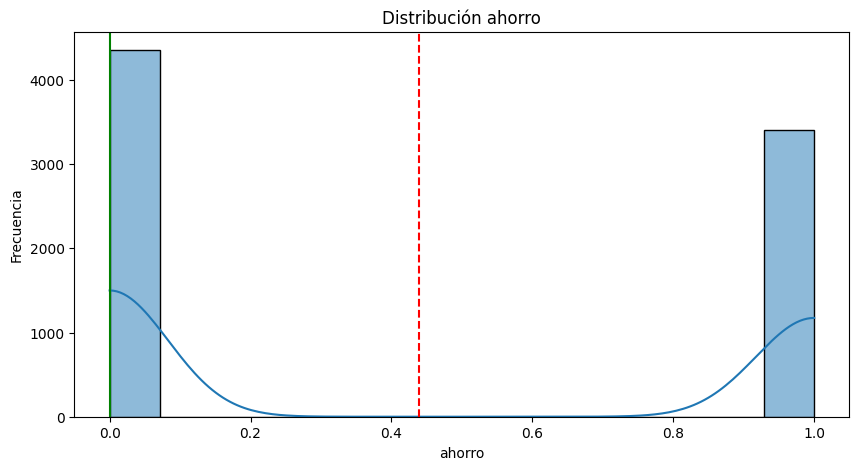

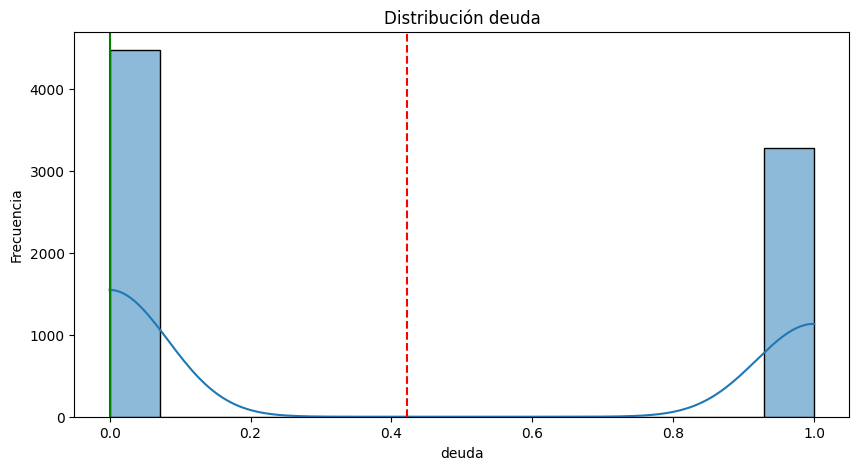

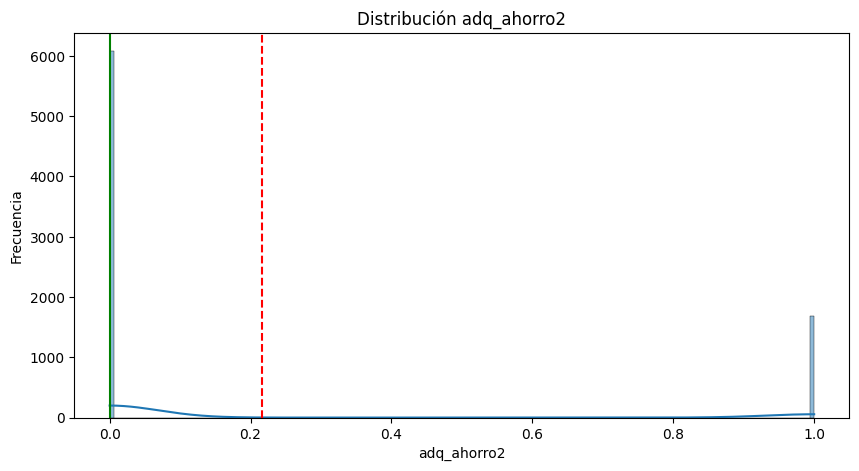

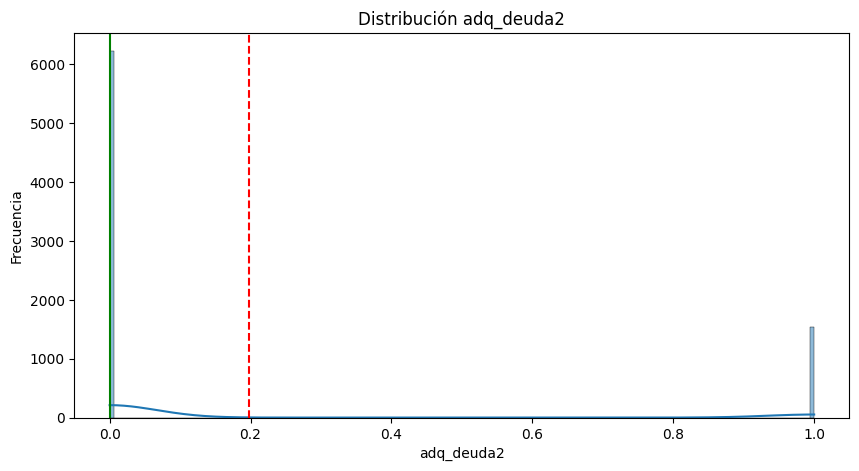

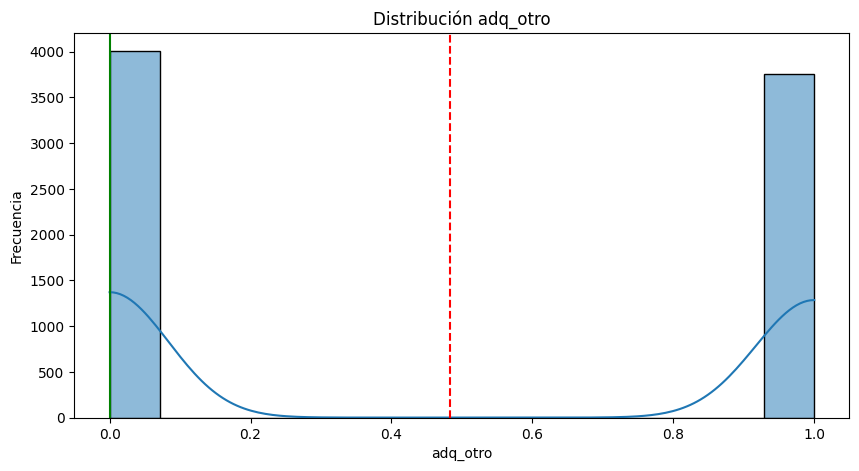

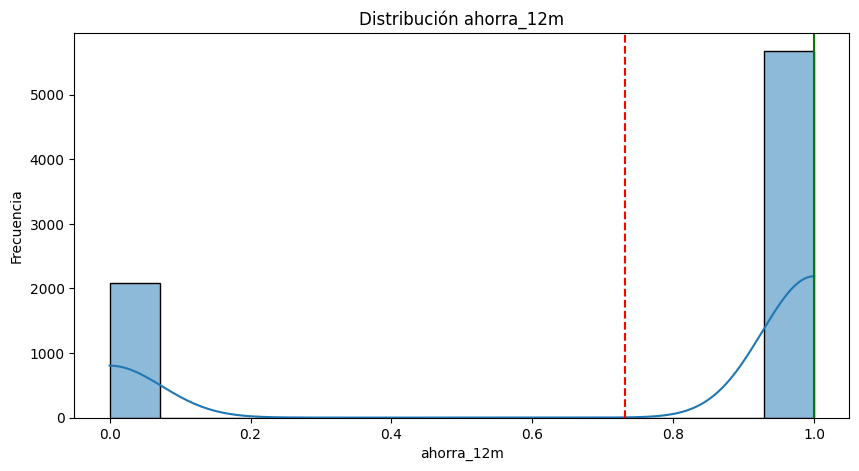

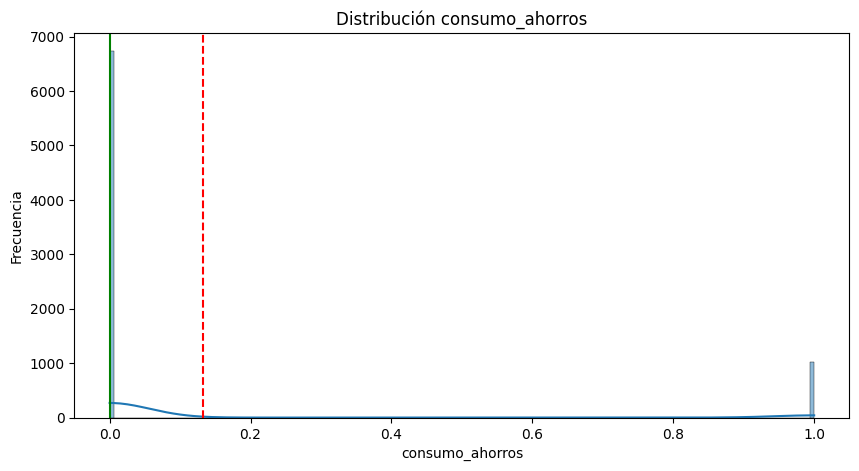

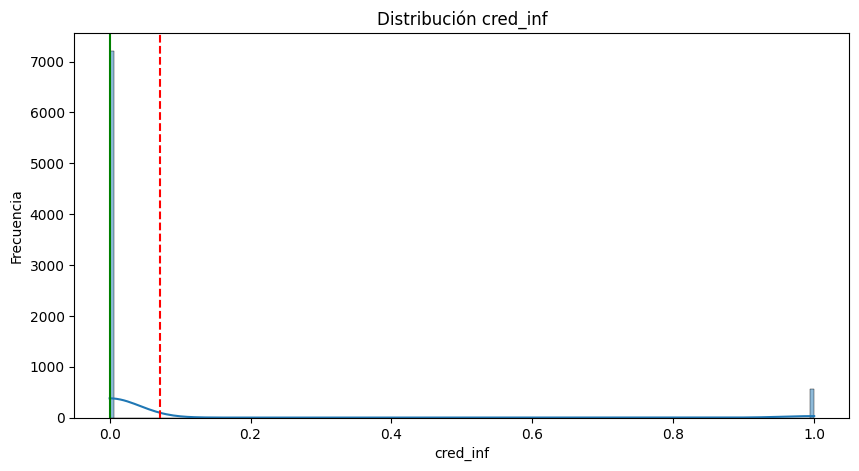

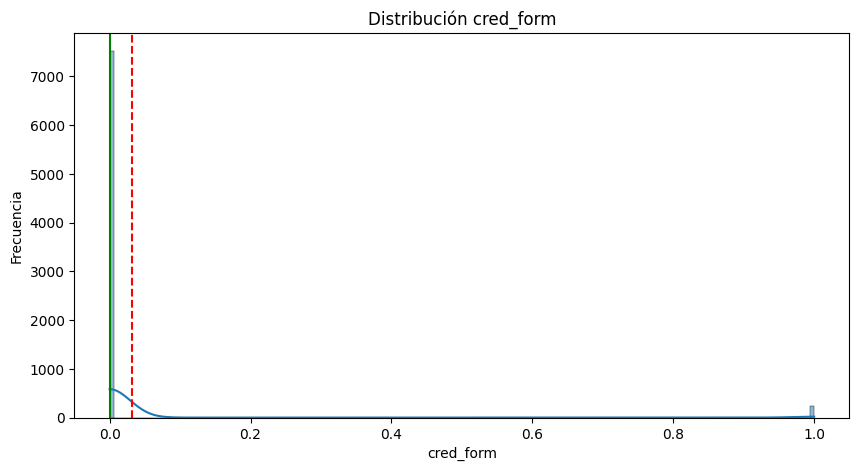

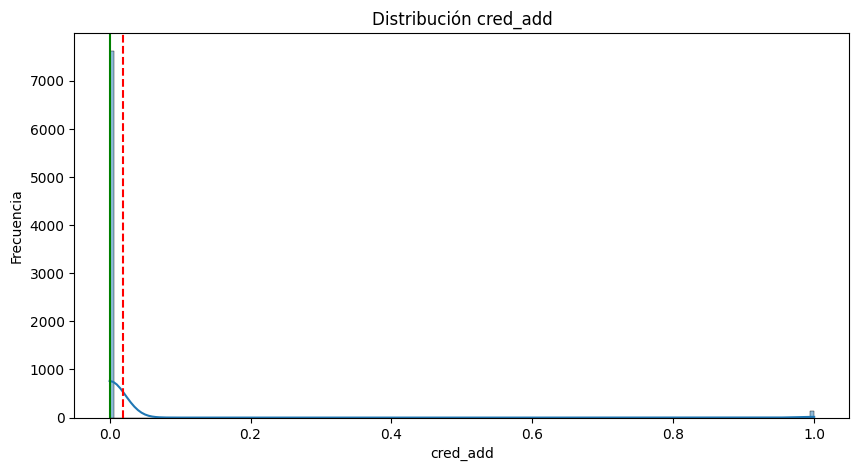

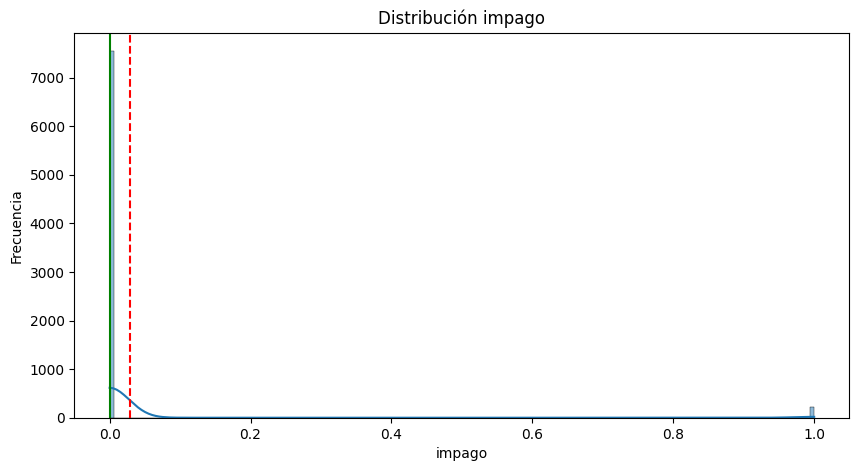

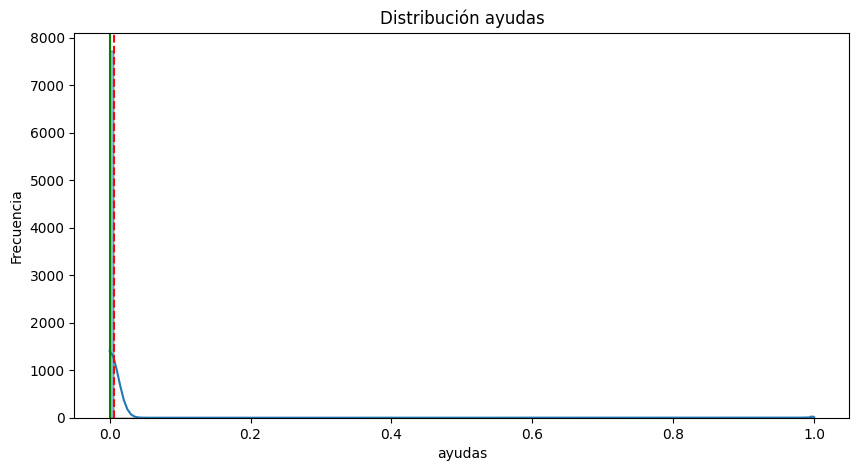

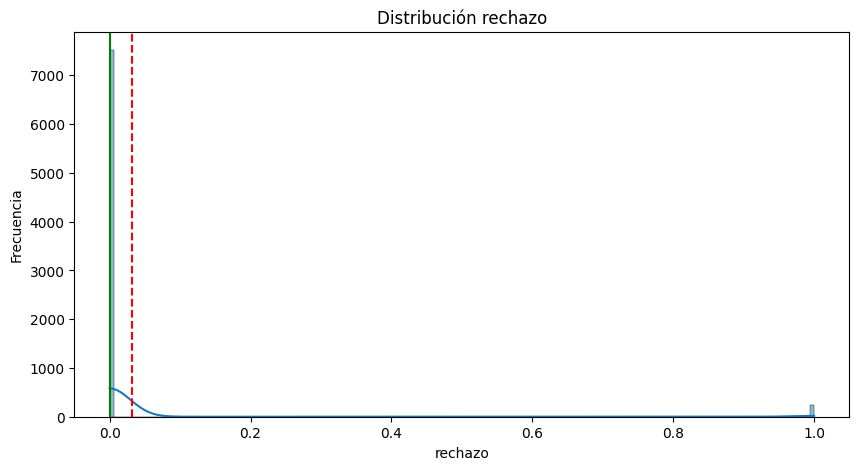

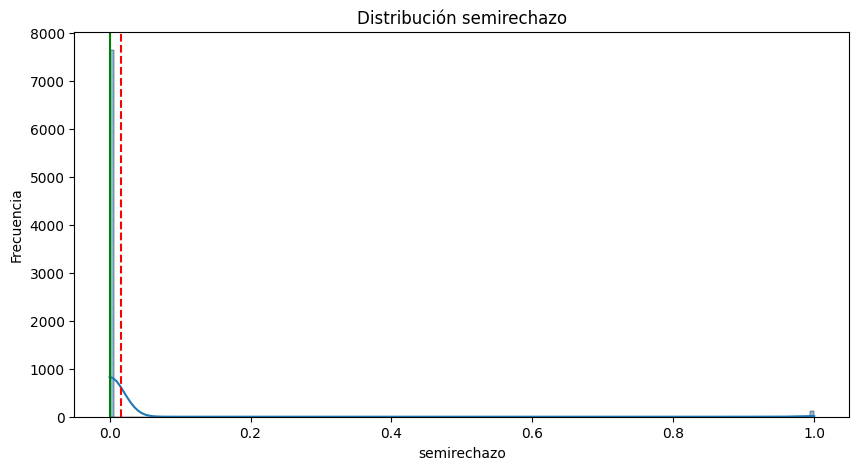

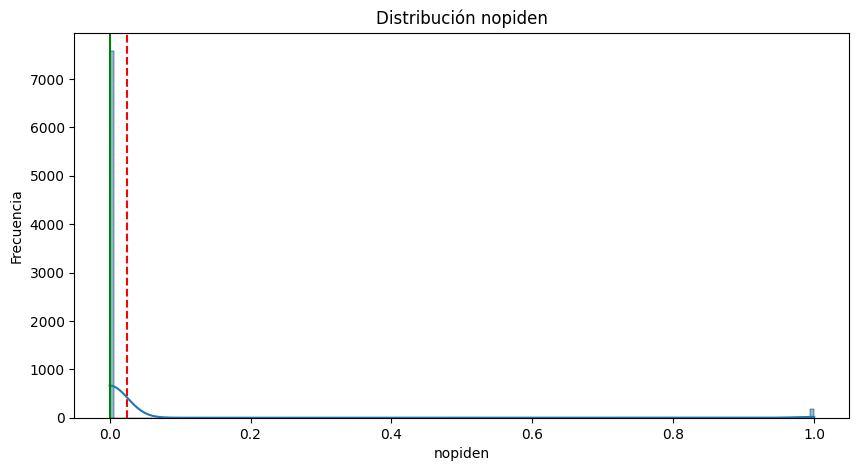

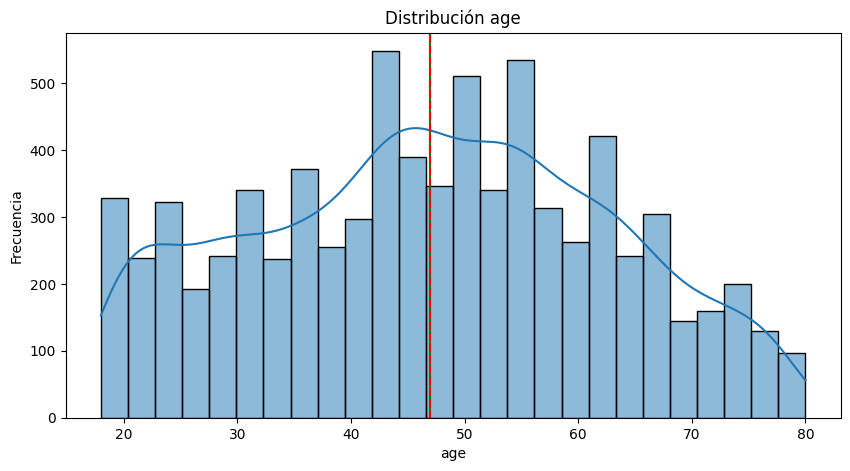

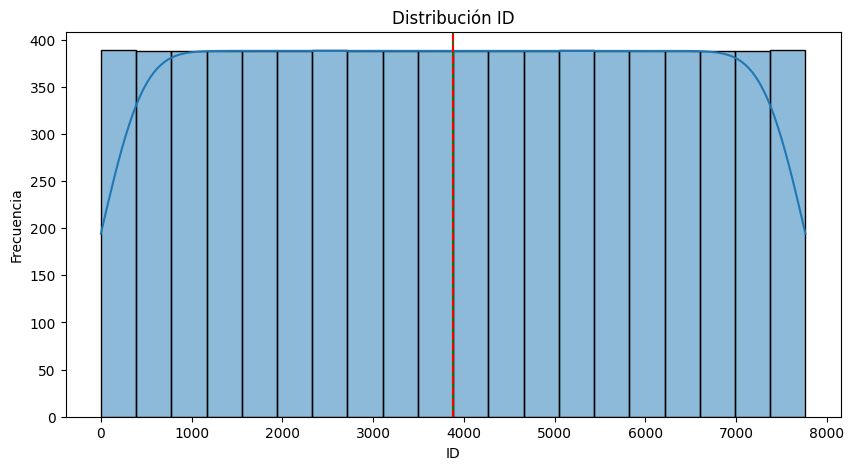

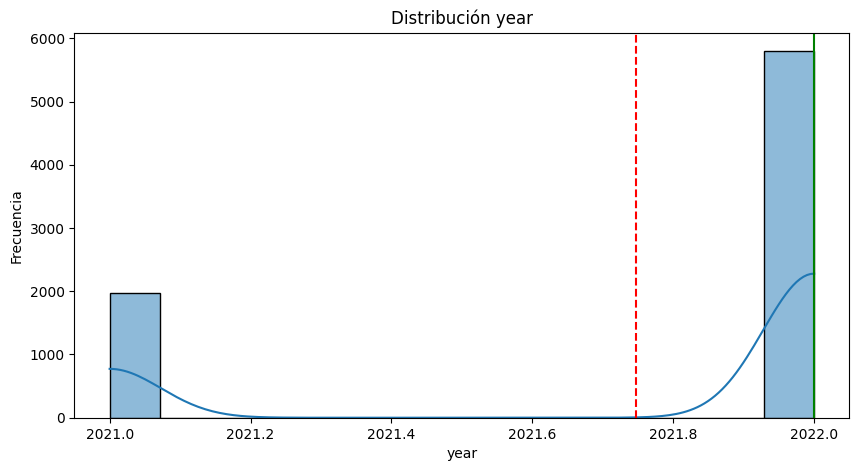

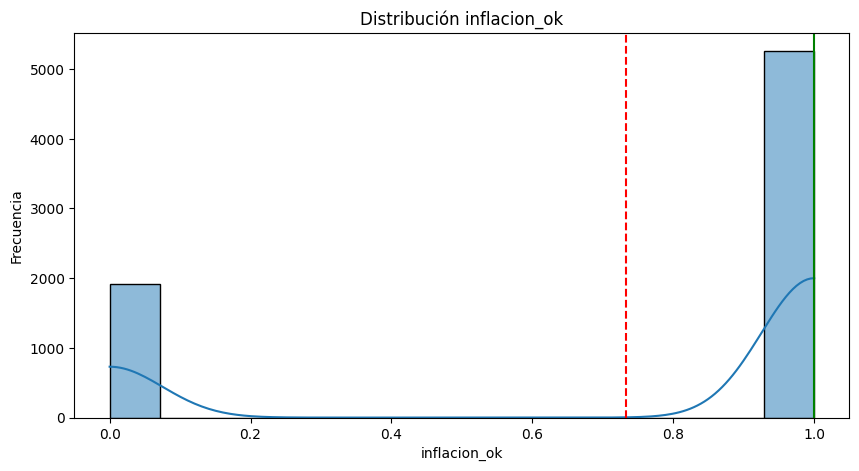

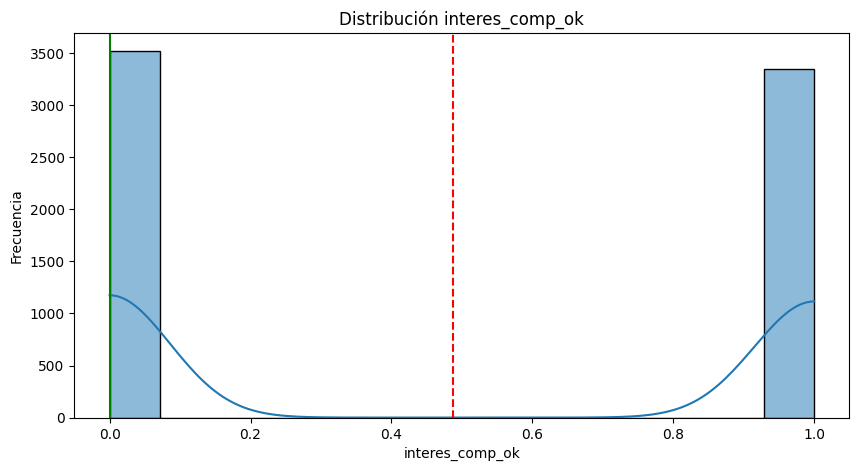

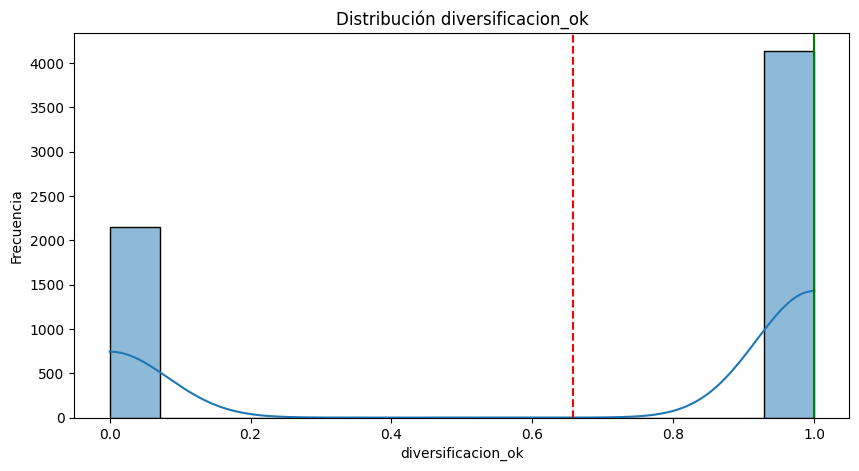

In [46]:
histogramas = auto_visualize_dataframe_histplot(df) 

histogramas

#### 4.3.2. Visualización de variables categóricas

In [49]:
def plot_categorical_distribution(df, exclude=None):
    if exclude is None:
        exclude = []
    
    cat_cols = df.select_dtypes(include='object').columns
    cat_cols = [col for col in cat_cols if col not in exclude]

    for col in cat_cols:
        percentages = df[col].value_counts(normalize=True) * 100

        plt.figure()
        plt.bar(percentages.index.astype(str), percentages.values)
        plt.title(f'Distribución porcentual de {col}')
        plt.ylabel('Porcentaje (%)')
        plt.xlabel(col)
        plt.xticks(rotation=45)
        plt.show()

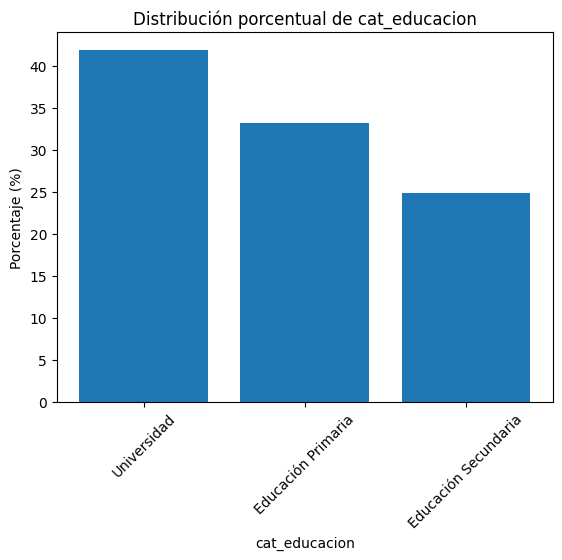

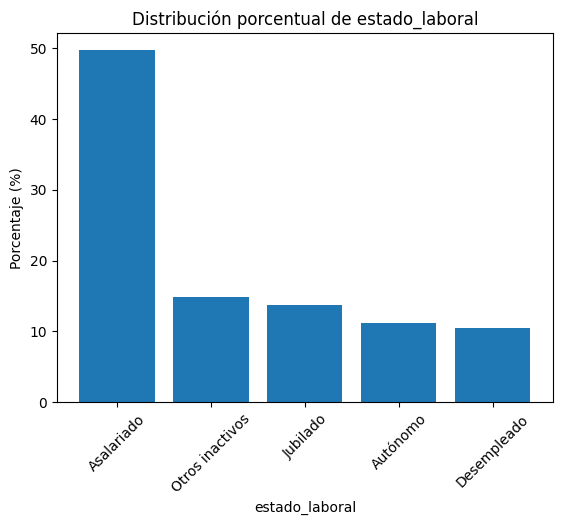

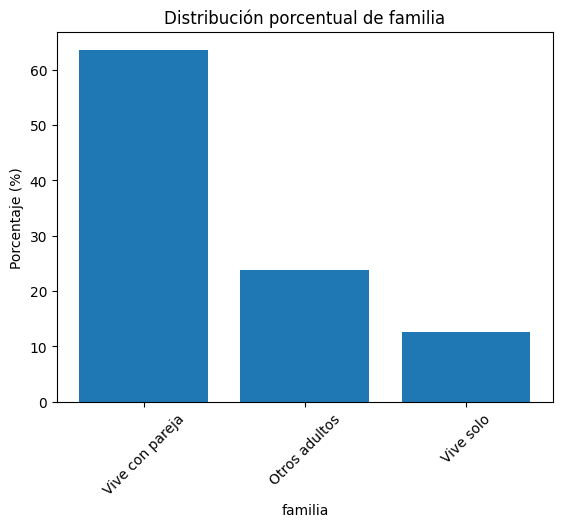

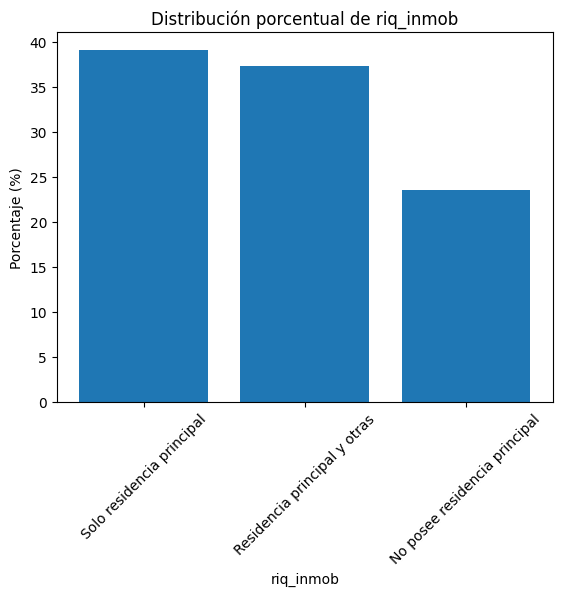

In [48]:
plot_categorical_distribution(df)